# Exploratory data analysis

Original MSc coursework, lightly prepared for the portfolio. Retained figures are historical submission outputs, not a fresh run. Missing datasets and methodological limitations are described in [README.md](README.md). Text logs and machine-specific metadata were removed; see the root EDITS.md for code fixes.


Run from this directory in order: `01-preprocessing.ipynb`, `02-feature-engineering.ipynb`, `03-eda.ipynb`, then `04-gradient-boosting.ipynb` and `05-random-forest.ipynb`.

In [5]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
X_train = pd.read_csv('data-prep/X_train.csv')
y_train = pd.read_csv('data-prep/y_train.csv')
X_test = pd.read_csv('data-prep/X_test.csv')
y_test = pd.read_csv('data-prep/y_test.csv')
X_kaggle = pd.read_csv('data-prep/X_kaggle.csv')

my_X_train = pd.read_csv('data-preprocess/new/X_train.csv')
my_y_train = pd.read_csv('data-preprocess/new/y_train.csv')
my_X_test = pd.read_csv('data-preprocess/new/X_test.csv')
my_y_test = pd.read_csv('data-preprocess/new/y_test.csv')
my_X_kaggle = pd.read_csv('data-preprocess/new/X_kaggle.csv')

my_X_train.fillna(my_X_train.mean(), inplace=True)
my_X_test.fillna(my_X_test.mean(), inplace=True)
my_X_kaggle.fillna(my_X_kaggle.mean(), inplace=True)

In [7]:
df = X_train.copy()
df['activity'] = y_train
df['activity'] = df['activity'].astype('category')

# Overview
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['activity'].value_counts())
display(df.describe())
display(df['activity'].describe())

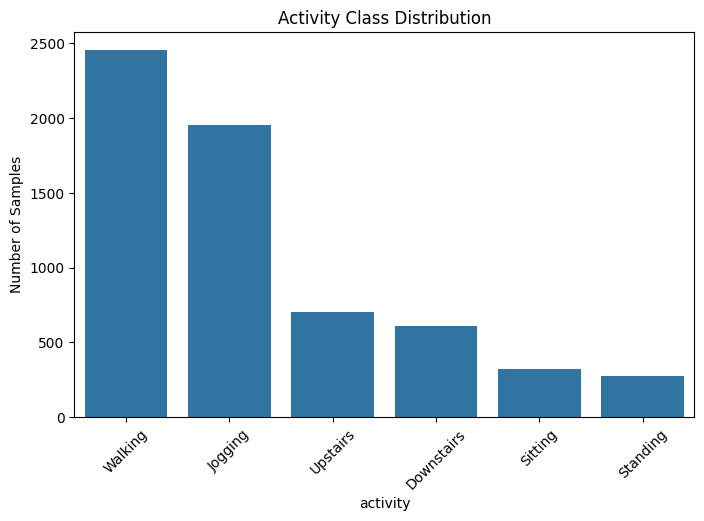

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='activity', data=df, order=df['activity'].value_counts().index)
plt.title("Activity Class Distribution")
plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_combined = np.vstack((X_train, X_test))
X_combined_scaled = scaler.fit_transform(X_combined)

y_combined = pd.concat([y_train, y_test], axis=0)

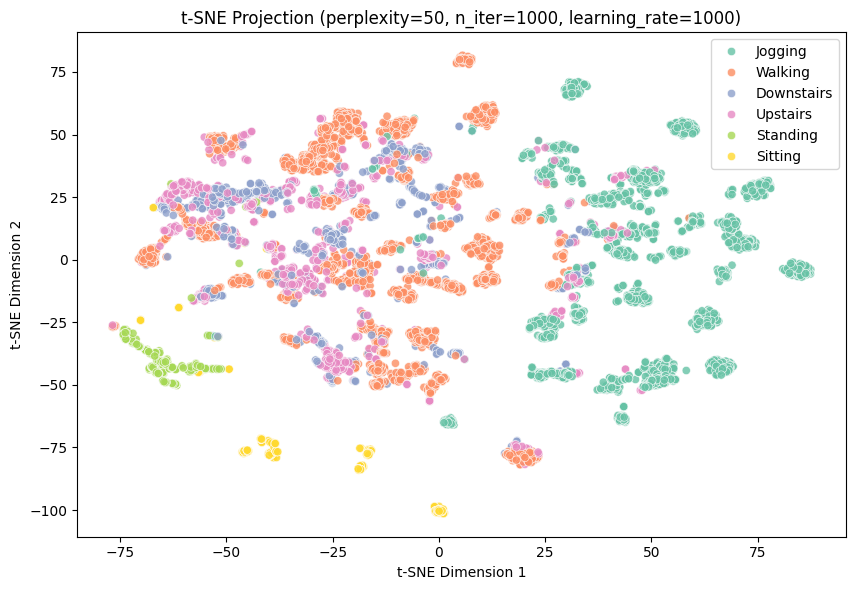

In [10]:
from sklearn.manifold import TSNE
param_grid = [
    (50, 1000, 1000),
]

y_plot = y_combined["activity"].reset_index(drop=True)
for perplexity, n_iter, learning_rate in param_grid:
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=n_iter, learning_rate=learning_rate)
    X_tsne = tsne.fit_transform(X_combined_scaled)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_plot, palette='Set2', alpha=0.8)
    plt.title(f"t-SNE Projection (perplexity={perplexity}, n_iter={n_iter}, learning_rate={learning_rate})")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

In [16]:
# Scale the features
scaler = StandardScaler()
my_X_train_scaled = scaler.fit_transform(my_X_train)
my_X_test_scaled = scaler.transform(my_X_test)
my_X_combined = np.vstack((my_X_train, my_X_test))
my_X_combined_scaled = scaler.fit_transform(my_X_combined)

my_y_combined = pd.concat([my_y_train, my_y_test], axis=0)

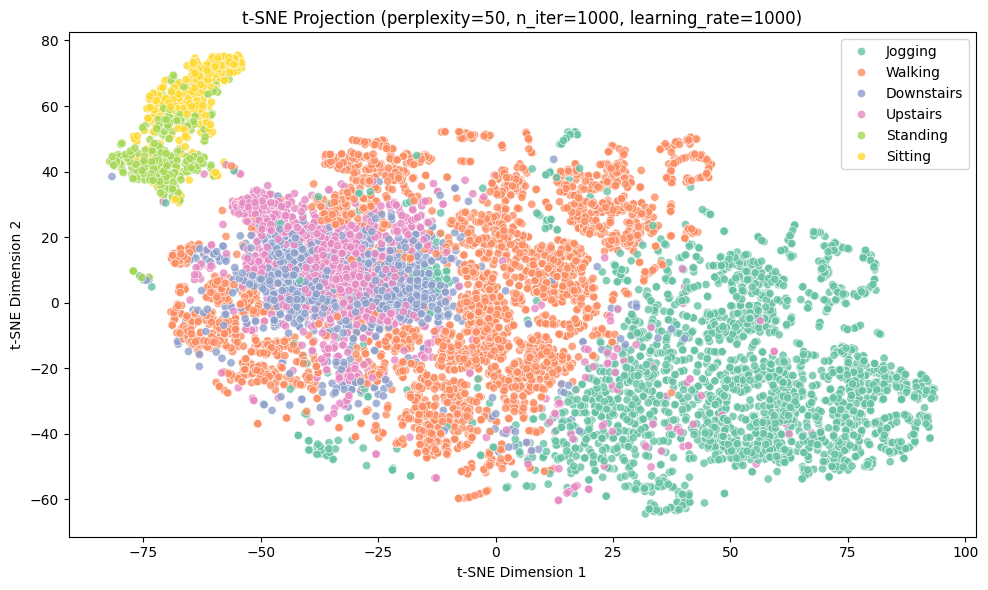

In [17]:
from sklearn.manifold import TSNE
param_grid = [
    (50, 1000, 1000),
]

my_y_plot = my_y_combined["activity"].reset_index(drop=True)
for perplexity, n_iter, learning_rate in param_grid:
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=n_iter, learning_rate=learning_rate)
    my_X_tsne = tsne.fit_transform(my_X_combined_scaled)
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=my_X_tsne[:, 0], y=my_X_tsne[:, 1], hue=my_y_plot, palette='Set2', alpha=0.8)
    plt.title(f"t-SNE Projection (perplexity={perplexity}, n_iter={n_iter}, learning_rate={learning_rate})")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(loc='best', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()